In [63]:
### Yashish's input ###

In [8]:
import scanpy as sc
import pandas as pd
import liana as li

In [9]:
adata = sc.read_h5ad("adata_xeno_with_symbols.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 75467 × 41560
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample', 'in_meta'
    var: 'raw_name', 'xeno_symbol', 'ORTHOLOG_HUMAN_SYMBOL'


In [10]:
### Inspect ###
print(adata.var.columns.tolist())
print(adata.var.head())

['raw_name', 'xeno_symbol', 'ORTHOLOG_HUMAN_SYMBOL']
                                                raw_name        xeno_symbol  \
gene25011|Xelaev18004747m      gene25011|Xelaev18004747m    Xelaev18004747m   
gene21250|Xetrov90028798m.L  gene21250|Xetrov90028798m.L  Xetrov90028798m.L   
gene27977|Xelaev18004749m      gene27977|Xelaev18004749m    Xelaev18004749m   
gene26149|Xelaev18004750m      gene26149|Xelaev18004750m    Xelaev18004750m   
gene25611|Xelaev18004751m      gene25611|Xelaev18004751m    Xelaev18004751m   

                            ORTHOLOG_HUMAN_SYMBOL  
gene25011|Xelaev18004747m                     NaN  
gene21250|Xetrov90028798m.L                   NaN  
gene27977|Xelaev18004749m                     NaN  
gene26149|Xelaev18004750m                     NaN  
gene25611|Xelaev18004751m                     NaN  


In [11]:
adata = sc.read_h5ad("adata_xeno_with_symbols.h5ad")
adata = adata[adata.obs["Phenograph"].notna()].copy()
adata = adata[:, adata.var["ORTHOLOG_HUMAN_SYMBOL"].notna()].copy()
adata.var_names = adata.var["ORTHOLOG_HUMAN_SYMBOL"].astype(str)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 33985 × 16028
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample', 'in_meta'
    var: 'raw_name', 'xeno_symbol', 'ORTHOLOG_HUMAN_SYMBOL'


In [ ]:
### Inspect ###

In [17]:
mask = adata.obs["Phenograph"].notna() & adata.obs["CellType"].isna()
adata.obs.loc[mask, ["Phenograph", "CellType"]].head(20)

,Phenograph,CellType
AAACCTGAGTGCGTGA-1-GSM4790538_scCapSt13_count.out.tar,Mcc/CCPs,NaN
AAACGGGAGAGCCCAA-1-GSM4790538_scCapSt13_count.out.tar,Eep4,NaN
AAACGGGAGCGTGAGT-1-GSM4790538_scCapSt13_count.out.tar,Mcc/CCPs,NaN
AAACGGGGTACGAAAT-1-GSM4790538_scCapSt13_count.out.tar,Mcc/CCPs,NaN
AAACGGGGTCTCCACT-1-GSM4790538_scCapSt13_count.out.tar,Mcc/CCPs,NaN
AAACGGGTCCGCATAA-1-GSM4790538_scCapSt13_count.out.tar,Mcc/CCPs,NaN
AAACGGGTCTGCCAGG-1-GSM4790538_scCapSt13_count.out.tar,Eep4,NaN
AAAGATGAGACGACGT-1-GSM4790538_scCapSt13_count.out.tar,Mcc/CCPs,NaN
AAAGATGGTACTTGAC-1-GSM4790538_scCapSt13_count.out.tar,Mcc/CCPs,NaN
AAAGATGGTCAAACTC-1-GSM4790538_scCapSt13_count.out.tar,Eep4,NaN


In [18]:
mask = adata.obs["Phenograph"].notna() & adata.obs["CellType"].isna()
print("Cells with Phenograph present but CellType missing:", mask.sum())

Cells with Phenograph present but CellType missing: 4185


In [ ]:
### Even though the phenotype is there the cell type annotations are still missing for 4185 cells ###

In [12]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

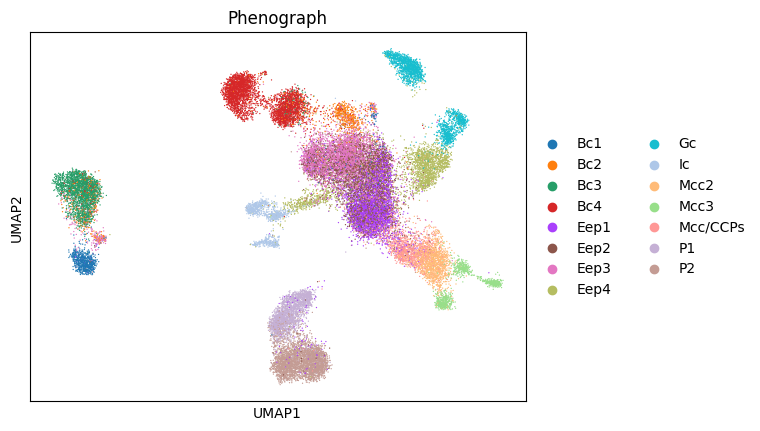

In [13]:
sc.pl.umap(adata, color="Phenograph")

In [14]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [15]:
adata_st22 = adata[adata.obs["Stages"] == "st22"].copy()

In [16]:
adata_st22.var_names

Index(['SUCLG1', 'ADRA1D', 'SMOX', 'RNF24', 'GNRH2', 'AVP', 'UBOX5', 'LZTS3',
       'ATRN', 'SLC4A11',
       ...
       'CLDN6-2', 'SRRM2-1', 'PHGDH-1', 'RRAGA-1', 'GBP7', 'GBP4', 'PPIL3',
       'NIF3L1', 'RNF112', 'MFAP4'],
      dtype='object', name='ORTHOLOG_HUMAN_SYMBOL', length=16028)

In [ ]:
### INSPECT ###

In [21]:
mask_st22 = adata_st22.obs["Phenograph"].notna() & adata_st22.obs["CellType"].isna()
print("st22 cells with Phenograph present but CellType missing:", mask_st22.sum())

st22 cells with Phenograph present but CellType missing: 21


In [22]:
adata_st22.obs.loc[mask_st22, ["Stages", "Phenograph", "CellType"]].head(20)

,Stages,Phenograph,CellType
AAATGGAGTGTTTACG-1-GSM4790542_scCapSt22_count.v3.out.tar,st22,Eep4,NaN
AATCGACTCTGCCTCA-1-GSM4790542_scCapSt22_count.v3.out.tar,st22,Eep4,NaN
AATGACCCACCTTCGT-1-GSM4790542_scCapSt22_count.v3.out.tar,st22,Eep4,NaN
ACGTAACAGGCCTGCT-1-GSM4790542_scCapSt22_count.v3.out.tar,st22,Mcc/CCPs,NaN
ATACTTCGTTTGTGGT-1-GSM4790542_scCapSt22_count.v3.out.tar,st22,Eep4,NaN
ATGCATGGTCCGGACT-1-GSM4790542_scCapSt22_count.v3.out.tar,st22,Eep4,NaN
CAACAACAGACCGTTT-1-GSM4790542_scCapSt22_count.v3.out.tar,st22,Eep4,NaN
CAGCGTGCATCCGTTC-1-GSM4790542_scCapSt22_count.v3.out.tar,st22,Eep4,NaN
CCTCCTCGTGTTCCAA-1-GSM4790542_scCapSt22_count.v3.out.tar,st22,Eep4,NaN
CGCAGGTTCGCTTACC-1-GSM4790542_scCapSt22_count.v3.out.tar,st22,Eep4,NaN


In [ ]:
### There are 21 cells in st22 with missing cell type annotations ###

In [20]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [24]:
cellphonedb(
            adata_st22,
            groupby='CellType',
            resource_name='consensus',
            expr_prop=0.1,
            verbose=True,
            key_added='cpdb_res',
            use_raw=False
        )

Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2099 features of mat are empty, they will be removed.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.62 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5217 samples and 560 features


100%|██████████| 1000/1000 [00:00<00:00, 1003.46it/s]


In [25]:
li.mt.rank_aggregate(adata_st22, 
                     groupby='CellType',
                     resource_name='consensus',
                     expr_prop=0.01,
                     verbose=True,
                     use_raw=False)

Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2099 features of mat are empty, they will be removed.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.62 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5217 samples and 560 features
Assuming that counts were `natural` log-normalized!


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Running CellPhoneDB


100%|██████████| 1000/1000 [00:00<00:00, 1017.15it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [26]:
print(adata_st22.uns.keys())


odict_keys(['log1p', 'pca', 'neighbors', 'umap', 'Phenograph_colors', 'cpdb_res', 'liana_res'])


In [27]:
adata_st22.uns["liana_res"]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
227,Basal,Early epithelial progenitor,MDK,NCL,0.644004,0.000,0.158160,0.347303,0.248480,0.160680,0.961102,0.002750,0.000003
126,Basal,Basal,MDK,NCL,0.619229,0.000,0.151348,0.287955,0.325431,0.153760,0.960270,0.003608,0.000012
648,Early epithelial progenitor,Early epithelial progenitor,MDK,NCL,0.608106,0.000,0.075557,0.153026,0.127847,0.076761,0.944683,0.030077,0.000072
581,Early epithelial progenitor,Basal,MDK,NCL,0.583332,0.000,0.072303,0.093677,0.204798,0.073455,0.943521,0.079417,0.000104
311,Basal,Goblet,MDK,NCL,0.467685,1.000,0.109684,-0.075070,-0.063350,0.111432,0.953652,1.000000,0.000350
...,...,...,...,...,...,...,...,...,...,...,...,...,...
941,Goblet,Basal,WNT3A,LRP1,0.009101,0.016,0.000081,0.036147,0.007972,0.286338,0.358509,0.055851,1.000000
963,Goblet,Early epithelial progenitor,GNAI2,CHRM1,0.008991,0.001,0.000076,0.257414,0.008592,0.222373,0.351291,0.030014,1.000000
1,Basal,Basal,ADAM10,GPNMB,0.007914,0.154,0.000055,0.005866,0.001884,0.033956,0.314905,0.991964,1.000000
977,Goblet,Early epithelial progenitor,MDK,ITGA6_ITGB1,0.008368,1.000,0.000070,-0.287983,-0.101484,0.004918,0.341470,1.000000,1.000000


In [28]:
res = adata_st22.uns["liana_res"]
print(res.columns)


Index(['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means',
       'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc',
       'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank'],
      dtype='object')


In [29]:
paper_xeno = [
    "has1.S", "eef1ao.L",
    "tubb4b.L", "dynll1.S", "tekt2.S", "cav3.S",
    "foxa1.L", "tp63.L", "pfn1.L", "ano1.L", "anxa2.S",
    "angpt4.S", "itln1.L", "atp12a.L", "otog.L", "otogl2.L", "mucXS",
    "foxi1.S", "atp6v1g3.S", "atp6v1b1.L", "ca2.L", "cystm1.S",
    "notch2.L", "hes1.L", "hes8.L", "smad3.L", "smad7.L"
]

check = (
    adata.var[["xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"]]
    .drop_duplicates()
)

check[check["xeno_symbol"].isin(paper_xeno)].sort_values("xeno_symbol")


,xeno_symbol,ORTHOLOG_HUMAN_SYMBOL
ORTHOLOG_HUMAN_SYMBOL,,
ANGPT4-1,angpt4.S,ANGPT4
ANO1,ano1.L,ANO1
ANXA2-1,anxa2.S,ANXA2
ATP6V1B1,atp6v1b1.L,ATP6V1B1
ATP6V1G3-1,atp6v1g3.S,ATP6V1G3
ATP12A,atp12a.L,ATP12A
CA2,ca2.L,CA2
CYSTM1-1,cystm1.S,CYSTM1
DYNLL1-1,dynll1.S,DYNLL1


In [30]:
resource = li.rs.select_resource("consensus")
lr_genes = set(resource["ligand"]).union(set(resource["receptor"]))

paper_human = set(
    check[check["xeno_symbol"].isin(paper_xeno)]["ORTHOLOG_HUMAN_SYMBOL"]
)

print("In data:", sorted(set(paper_human) & set(adata_st22.var_names)))
print("In LR resource:", sorted(set(paper_human) & lr_genes))
print("In both:", sorted(set(paper_human) & set(adata_st22.var_names) & lr_genes))


In data: ['ANGPT4', 'ANO1', 'ANXA2', 'ATP12A', 'ATP6V1B1', 'ATP6V1G3', 'CA2', 'CYSTM1', 'DYNLL1', 'FOXA1', 'FOXI1', 'HAS1', 'HES1', 'ITLN1', 'NOTCH2', 'OTOG', 'PFN1', 'SMAD3', 'SMAD7', 'TEKT2', 'TP63', 'TUBB4B']
In LR resource: ['ANGPT4', 'ANXA2', 'NOTCH2']
In both: ['ANGPT4', 'ANXA2', 'NOTCH2']


In [31]:
gene =  ['ANGPT4', 'ANXA2', 'NOTCH2']
res_gen = set(res['ligand_complex']).union(set(res['receptor_complex']))


In [32]:
print(res_gen.intersection(gene))

{'NOTCH2'}


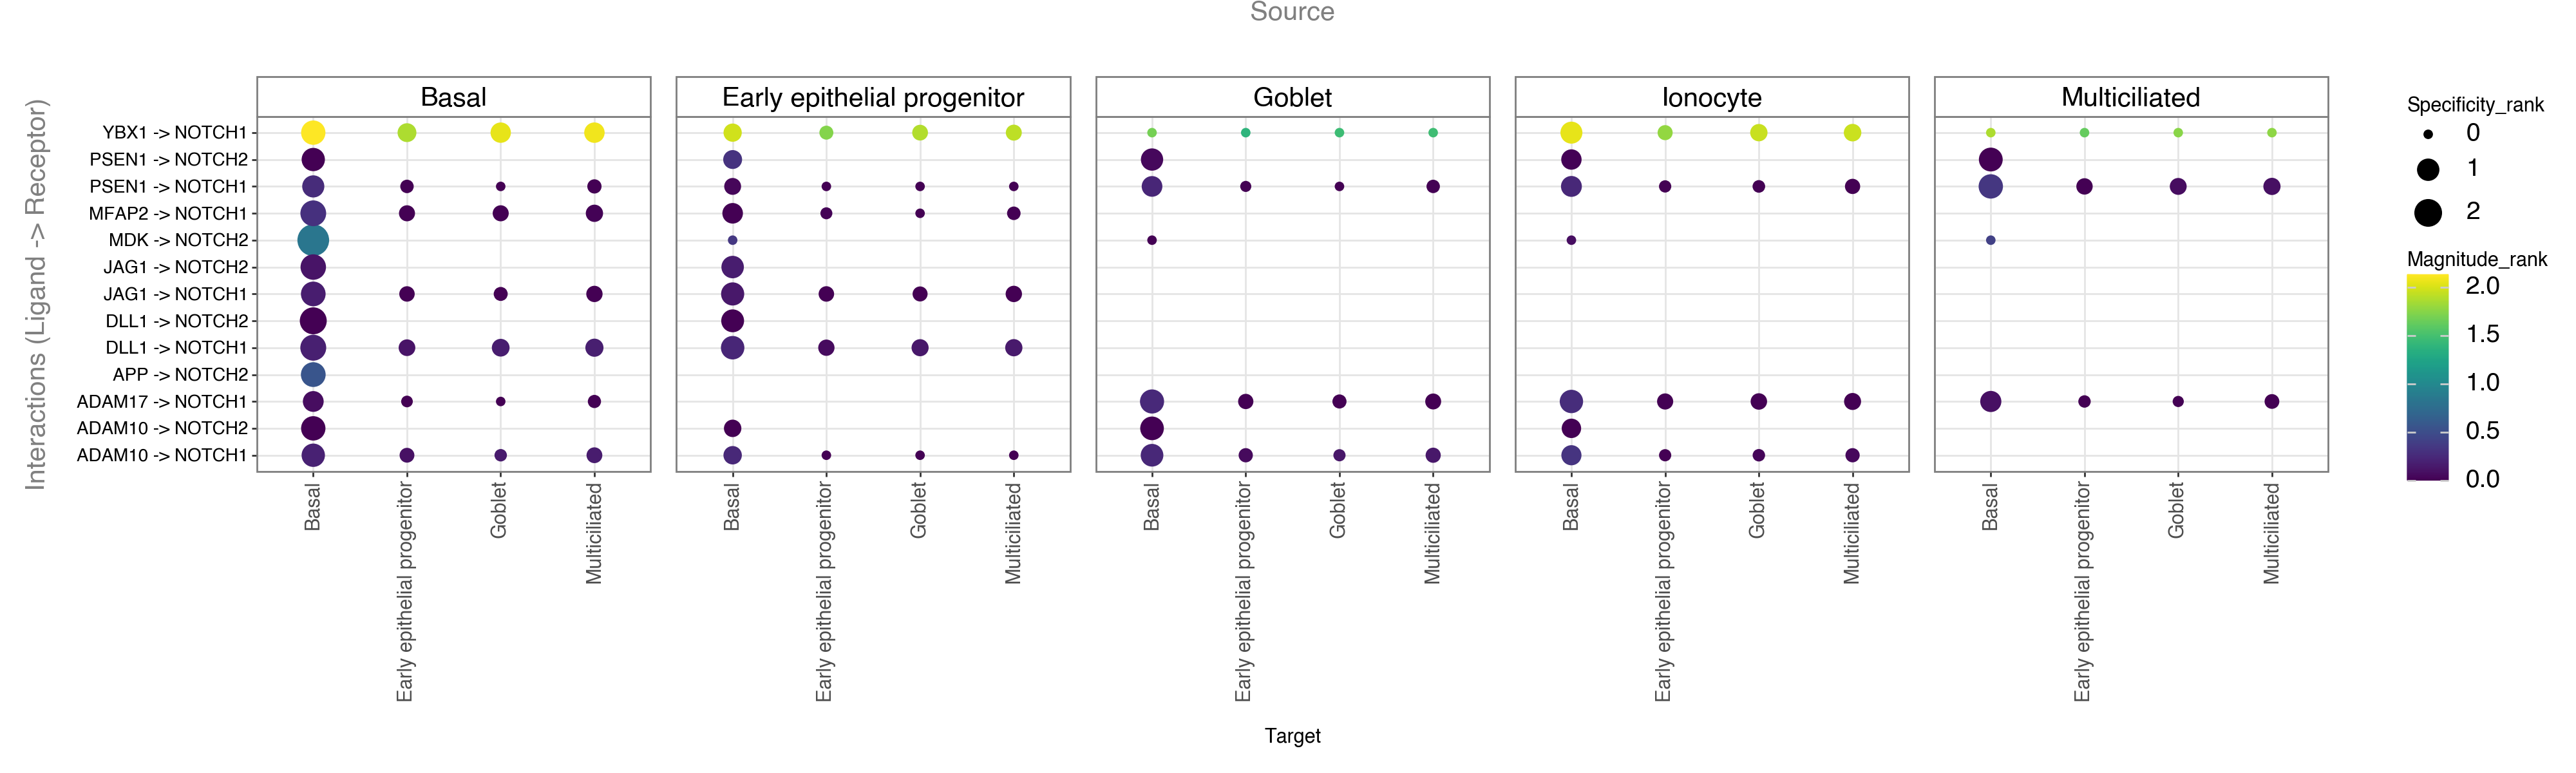

In [33]:
li.pl.dotplot(
    adata=adata_st22,
    uns_key="liana_res",
    receptor_complex=["NOTCH2","NOTCH1"],
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,
    inverse_size=True,
    figure_size=(20, 6)
)


In [ ]:
### ###

In [35]:
# check columns 
liana_res = adata_st22.uns["liana_res"]
print(liana_res.columns)

Index(['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means',
       'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc',
       'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank'],
      dtype='object')


In [56]:
# filter notch interactions
notch_res = liana_res[
    liana_res["receptor_complex"].str.contains("NOTCH", case=False, na=False)
].copy()

notch_res.head(20)

### 133 data enteries with 72% being Notch 1, and rest split between Notch 2 (14%) and Notch 3 (14%) ### 
### LIANA does detect Notch-family receptors in the dataset ###

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
172,Basal,Basal,YBX1,NOTCH1,0.222389,0.000,0.007478,0.110719,0.112136,0.086076,0.843081,0.047405,0.007411
501,Basal,Multiciliated,YBX1,NOTCH1,0.219169,0.000,0.004726,0.065105,0.103134,0.054401,0.810292,0.191815,0.008299
338,Basal,Goblet,YBX1,NOTCH1,0.219088,0.000,0.004657,0.063953,0.102533,0.053601,0.809151,0.195542,0.008918
1269,Ionocyte,Basal,YBX1,NOTCH1,0.204353,0.124,0.006847,0.053722,0.016543,0.078809,0.837158,0.115563,0.008918
610,Early epithelial progenitor,Basal,YBX1,NOTCH1,0.193115,0.501,0.006454,0.018208,0.013683,0.074281,0.833084,0.347260,0.010561
1493,Ionocyte,Multiciliated,YBX1,NOTCH1,0.201133,0.205,0.004327,0.008107,0.007540,0.049808,0.803420,0.410248,0.010906
1380,Ionocyte,Goblet,YBX1,NOTCH1,0.201051,0.206,0.004264,0.006955,0.006939,0.049076,0.802248,0.428674,0.011257
834,Early epithelial progenitor,Multiciliated,YBX1,NOTCH1,0.189895,0.629,0.004079,-0.027406,0.004680,0.046947,0.798706,0.560883,0.011973
727,Early epithelial progenitor,Goblet,YBX1,NOTCH1,0.189813,0.614,0.004019,-0.028558,0.004080,0.046256,0.797512,0.582006,0.013089
1581,Multiciliated,Basal,YBX1,NOTCH1,0.171156,0.997,0.005685,-0.051185,-0.027904,0.065434,0.824080,1.000000,0.013471


In [40]:
# sorted by strength (lr_means)
notch_res.sort_values(by="lr_means", ascending=False).head(20)

### Result ###
# The top-ranked Notch interactions are dominated by YBX1 -> NOTCH1 across multiple sender–receiver pairs.
# This indicates that non-canonical Notch-associated interactions are the most prominent in the LIANA output.

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
172,Basal,Basal,YBX1,NOTCH1,0.222389,0.000,0.007478,0.110719,0.112136,0.086076,0.843081,0.047405,0.007411
501,Basal,Multiciliated,YBX1,NOTCH1,0.219169,0.000,0.004726,0.065105,0.103134,0.054401,0.810292,0.191815,0.008299
338,Basal,Goblet,YBX1,NOTCH1,0.219088,0.000,0.004657,0.063953,0.102533,0.053601,0.809151,0.195542,0.008918
254,Basal,Early epithelial progenitor,YBX1,NOTCH1,0.218291,0.000,0.003976,0.052668,0.101743,0.045765,0.796649,0.299843,0.013471
1269,Ionocyte,Basal,YBX1,NOTCH1,0.204353,0.124,0.006847,0.053722,0.016543,0.078809,0.837158,0.115563,0.008918
1493,Ionocyte,Multiciliated,YBX1,NOTCH1,0.201133,0.205,0.004327,0.008107,0.007540,0.049808,0.803420,0.410248,0.010906
1380,Ionocyte,Goblet,YBX1,NOTCH1,0.201051,0.206,0.004264,0.006955,0.006939,0.049076,0.802248,0.428674,0.011257
1319,Ionocyte,Early epithelial progenitor,YBX1,NOTCH1,0.200255,0.241,0.003640,-0.004329,0.006149,0.041901,0.789411,0.653627,0.016299
610,Early epithelial progenitor,Basal,YBX1,NOTCH1,0.193115,0.501,0.006454,0.018208,0.013683,0.074281,0.833084,0.347260,0.010561
834,Early epithelial progenitor,Multiciliated,YBX1,NOTCH1,0.189895,0.629,0.004079,-0.027406,0.004680,0.046947,0.798706,0.560883,0.011973


In [57]:
# Check YBX1-NOTCH2 interactions
liana_res[
    (liana_res["ligand_complex"] == "YBX1") &
    (liana_res["receptor_complex"].str.contains("NOTCH2", case=False, na=False))
]
### No YBX1 -> NOTCH2 interactions were detected in thus stage 22 subset ###

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank


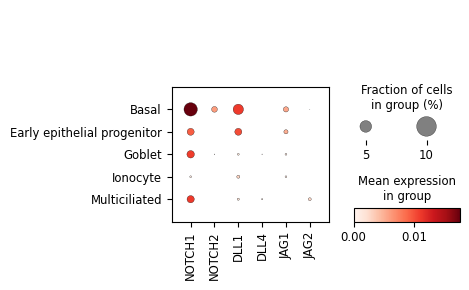

In [50]:
# Dotplot
genes_to_check = ["NOTCH1", "NOTCH2", "DLL1", "DLL4", "JAG1", "JAG2"]

sc.pl.dotplot(
    adata_st22,
    var_names=["NOTCH1", "NOTCH2", "DLL1", "DLL4", "JAG1", "JAG2"],
    groupby="CellType",
    use_raw=False
)
###  NOTCH1 and NOTCH2 show broader expression than the ligands, while DLL1, DLL4, and JAG1 are expressed at lower levels.
# JAG2 is nearly absent or very weakly expressed. ###

In [52]:
# Summarize st22 expressions of canconical Notch genes by cell types
import pandas as pd
import numpy as np

genes = ["NOTCH1", "NOTCH2", "DLL1", "DLL4", "JAG1", "JAG2"]
genes = [g for g in genes if g in adata_st22.var_names]

summary_rows = []

for celltype in adata_st22.obs["CellType"].dropna().unique():
    ad = adata_st22[adata_st22.obs["CellType"] == celltype, genes]

    X = ad.X
    if not isinstance(X, np.ndarray):
        X = X.toarray()

    mean_expr = X.mean(axis=0) 
    pct_expr = (X > 0).mean(axis=0) * 100

    for i, gene in enumerate(genes):
        summary_rows.append({
            "CellType": celltype,
            "Gene": gene,
            "MeanExpression": mean_expr[i],
            "PercentExpressing": pct_expr[i]
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

### RESULTS ###
# NOTCH1 is the most broadly detected receptor across cell types.
# NOTCH2 is present but more restricted.
# DLL1 and JAG1 are detectable in selected cell types, whereas DLL4 and especially JAG2 are weaker.
# This confirms that canonical Notch components are transcriptionally present, but generally at low expression levels.

,CellType,Gene,MeanExpression,PercentExpressing
0,Multiciliated,NOTCH1,0.011062,2.652520
1,Multiciliated,NOTCH2,0.000000,0.000000
2,Multiciliated,DLL1,0.002116,0.530504
3,Multiciliated,DLL4,0.000881,0.265252
4,Multiciliated,JAG1,0.000000,0.000000
5,Multiciliated,JAG2,0.002751,0.795756
6,Goblet,NOTCH1,0.010899,2.761001
7,Goblet,NOTCH2,0.000245,0.086281
8,Goblet,DLL1,0.001538,0.431406
9,Goblet,DLL4,0.000259,0.086281


In [54]:
# check receptors (NOTCH)
liana_res[
    liana_res["receptor_complex"].isin(["NOTCH1", "NOTCH2", "NOTCH3"])
]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
172,Basal,Basal,YBX1,NOTCH1,0.222389,0.000,0.007478,0.110719,0.112136,0.086076,0.843081,0.047405,0.007411
501,Basal,Multiciliated,YBX1,NOTCH1,0.219169,0.000,0.004726,0.065105,0.103134,0.054401,0.810292,0.191815,0.008299
338,Basal,Goblet,YBX1,NOTCH1,0.219088,0.000,0.004657,0.063953,0.102533,0.053601,0.809151,0.195542,0.008918
1269,Ionocyte,Basal,YBX1,NOTCH1,0.204353,0.124,0.006847,0.053722,0.016543,0.078809,0.837158,0.115563,0.008918
610,Early epithelial progenitor,Basal,YBX1,NOTCH1,0.193115,0.501,0.006454,0.018208,0.013683,0.074281,0.833084,0.347260,0.010561
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,Goblet,Goblet,PSEN1,NOTCH1,0.008403,0.974,0.000064,-0.031052,-0.003794,0.040593,0.332672,1.000000,1.000000
1719,Multiciliated,Multiciliated,ADAM17,NOTCH1,0.007914,0.817,0.000053,-0.026314,-0.002685,0.042669,0.310892,0.685019,1.000000
1000,Goblet,Goblet,ADAM17,NOTCH1,0.008647,0.843,0.000070,-0.008404,-0.001663,0.056404,0.341545,0.747610,1.000000
3,Basal,Basal,ADAM10,NOTCH2,0.008404,0.000,0.000065,0.041697,0.007720,0.279539,0.334145,0.046529,1.000000


In [55]:
# Check ligands (DLL/JAG)
liana_res[
    liana_res["ligand_complex"].isin(["DLL1", "DLL4", "JAG1", "JAG2"])
]

### Canonical Notch ligand interactions are detected by LIANA, including DLL1 -> NOTCH1/2 ###
### and JAG1 -> NOTCH1/2/3. ###
### However, these interactions are much fewer and generally weaker than the dominant YBX1 -> NOTCH1 interactions. ###

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
695,Early epithelial progenitor,Goblet,JAG1,NOTCH3,0.004319,1.000,0.000018,-0.063309,-0.010939,0.047153,0.209047,1.000000,0.190153
298,Basal,Goblet,JAG1,NOTCH3,0.004486,1.000,0.000019,-0.058653,-0.008829,0.050259,0.214370,1.000000,0.209688
99,Basal,Basal,JAG1,NOTCH3,0.013969,0.000,0.000122,0.077751,0.020341,0.317186,0.406697,0.007898,0.454142
557,Early epithelial progenitor,Basal,JAG1,NOTCH3,0.013802,0.000,0.000114,0.073094,0.018232,0.297584,0.399025,0.009644,0.511603
527,Early epithelial progenitor,Basal,DLL1,NOTCH1,0.013843,0.050,0.000178,0.046665,0.008900,0.128815,0.453393,0.067136,0.596066
48,Basal,Basal,DLL1,NOTCH1,0.014254,0.000,0.000193,0.055129,0.013035,0.139196,0.463013,0.024032,0.655392
445,Basal,Multiciliated,DLL1,NOTCH1,0.011033,0.516,0.000122,0.009514,0.004032,0.087974,0.406696,0.357288,0.660972
277,Basal,Goblet,DLL1,NOTCH1,0.010952,0.549,0.000120,0.008363,0.003432,0.086680,0.404910,0.392292,0.672228
97,Basal,Basal,JAG1,NOTCH1,0.011452,0.000,0.000095,0.044304,0.009805,0.150292,0.376599,0.040998,0.672228
556,Early epithelial progenitor,Basal,JAG1,NOTCH2,0.005576,0.099,0.000031,0.049323,0.006535,0.385837,0.256487,0.097527,0.677759


In [61]:
comparison_matrix = comparison_matrix.sort_values(["Role", "Gene"]).reset_index(drop=True)
comparison_matrix

,Gene,Role,Present_in_expression_data,Detected_in_LIANA_interactions,Number_of_LIANA_interactions,Max_lr_means
0,DLL1,Ligand,True,True,14,0.016770
1,DLL4,Ligand,True,False,0,NaN
2,JAG1,Ligand,True,True,14,0.013969
3,JAG2,Ligand,True,False,0,NaN
4,NOTCH1,Receptor,True,True,16,0.014254
5,NOTCH2,Receptor,True,True,4,0.008544


In [62]:
# summarize expression across cell types for each gene
gene_expr_summary = (
    summary_df.groupby("Gene")
    .agg(
        MeanExpression_avg=("MeanExpression", "mean"),
        PercentExpressing_avg=("PercentExpressing", "mean"),
        MaxMeanExpression=("MeanExpression", "max"),
        MaxPercentExpressing=("PercentExpressing", "max")
    )
    .reset_index()
)

comparison_matrix_full = comparison_matrix.merge(
    gene_expr_summary,
    on="Gene",
    how="left"
)

comparison_matrix_full = comparison_matrix_full.sort_values(
    ["Role", "Gene"]
).reset_index(drop=True)

comparison_matrix_full

### Interpretation ###
# Expression of a ligand or receptor alone is not sufficient for LIANA to infer a cell–cell interaction.
# LIANA recovers only the subset of genes that satisfy interaction-level criteria across sender–receiver pairs.
# In this stage 22 dataset, DLL4 and JAG2 are expressed but remain too weak or too sparse to be recovered as canonical LIANA interactions,
# whereas DLL1 and JAG1 are detected and linked to NOTCH receptors.

,Gene,Role,Present_in_expression_data,Detected_in_LIANA_interactions,Number_of_LIANA_interactions,Max_lr_means,MeanExpression_avg,PercentExpressing_avg,MaxMeanExpression,MaxPercentExpressing
0,DLL1,Ligand,True,True,14,0.016770,0.00554,1.714,0.0110,4.24
1,DLL4,Ligand,True,False,0,NaN,0.00024,0.072,0.0009,0.27
2,JAG1,Ligand,True,True,14,0.013969,0.00254,0.770,0.0054,1.73
3,JAG2,Ligand,True,False,0,NaN,0.00058,0.166,0.0028,0.80
4,NOTCH1,Receptor,True,True,16,0.014254,0.00998,2.872,0.0175,6.00
5,NOTCH2,Receptor,True,True,4,0.008544,0.00126,0.408,0.0061,1.95
